In [1]:
# 1. Load MovieLens Dataset
import pandas as pd

Movies = pd.read_csv("MovieLens_Dataset\\movies.csv")
Ratings = pd.read_csv("MovieLens_Dataset\\ratings.csv")


In [2]:
#Display 1st 5 rows of Movies file
print(Movies.head())


   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [3]:
#Display 1st 5 rows of Ratings file
print(Ratings.head())

   userId  movieId  rating   timestamp
0       1       16     4.0  1217897793
1       1       24     1.5  1217895807
2       1       32     4.0  1217896246
3       1       47     4.0  1217896556
4       1       50     4.0  1217896523


In [4]:
# 2.Exploratory Data Analysis (EDA)
# Clean dataset
# a) Missing Values
# Check for Missing Values in each file
print(Movies.isnull().sum())
print(Ratings.isnull().sum())
#Output shows No Missing Values in each file

movieId    0
title      0
genres     0
dtype: int64
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [5]:
# 2b) Outliers
# i) Check for Outliers in Ratings file
# Use IQR Method
Q1Ra = Ratings['rating'].quantile(0.25)
Q3Ra = Ratings['rating'].quantile(0.75)
IQRRa = Q3Ra - Q1Ra

lower_bound = Q1Ra - 1.5 * IQRRa
upper_bound = Q3Ra+ 1.5 * IQRRa

outliers = Ratings[(Ratings['rating'] < lower_bound) | (Ratings['rating'] > upper_bound)]
print(outliers) 

# Save original ratings
original_ratings = Ratings['rating'].copy()

        userId  movieId  rating   timestamp
9            1      204     0.5  1217895786
11           1      256     0.5  1217895764
14           1      277     0.5  1217895772
31           1      719     0.5  1217895799
106          1    45950     0.5  1217897813
...        ...      ...     ...         ...
105265     668   118338     1.0  1436729297
105269     668   118702     1.0  1442706187
105280     668   120110     1.0  1443467490
105284     668   121308     0.5  1431030402
105305     668   130452     1.0  1436465535

[4456 rows x 4 columns]


In [6]:
# Outliers in Movies file
# Select a numeric column 'movieId'
Q1Mo = Movies['movieId'].quantile(0.25)
Q3Mo = Movies['movieId'].quantile(0.75)
IQRMo = Q3Mo - Q1Mo

lower_bound = Q1Mo - 1.5 * IQRMo
upper_bound = Q3Mo + 1.5 * IQRMo

# Identify outliers
outliers = Movies[(Movies['movieId'] < lower_bound) | (Movies['movieId'] > upper_bound)]
print(outliers)

# Save original ratings
original_movies = Movies['movieId'].copy()


       movieId                                title                     genres
10321   144976                 Bone Tomahawk (2015)             Horror|Western
10322   146344          Elämältä kaiken sain (    )               Comedy|Drama
10323   146656                         Creed (2015)                      Drama
10324   146684        Cosmic Scrat-tastrophe (2015)  Animation|Children|Comedy
10325   146878           Le Grand Restaurant (1966)                     Comedy
10326   148238       A Very Murray Christmas (2015)                     Comedy
10327   148626                 The Big Short (2015)                      Drama
10328   149532  Marco Polo: One Hundred Eyes (2015)         (no genres listed)


In [7]:
# 2b ii)Handle the Outliers
# Use Winsorization
# Ratings file
Ratings['rating'] = Ratings['rating'].clip(lower_bound, upper_bound)

#Show changed rows
changed = Ratings[original_ratings != Ratings['rating']]

print(changed)
print("Number of changes:", len(changed))


Empty DataFrame
Columns: [userId, movieId, rating, timestamp]
Index: []
Number of changes: 0


In [8]:
# Handle the Outliers
# Outliers in Movies file
# Select a numeric column 'movieId'
Movies['movieId'] = Movies['movieId'].clip(lower_bound, upper_bound)

# Show changed rows
changed = Movies[original_movies != Movies['movieId']]

print(changed)
print("Number of changes:", len(changed))


       movieId                                title                     genres
10321   144890                 Bone Tomahawk (2015)             Horror|Western
10322   144890          Elämältä kaiken sain (    )               Comedy|Drama
10323   144890                         Creed (2015)                      Drama
10324   144890        Cosmic Scrat-tastrophe (2015)  Animation|Children|Comedy
10325   144890           Le Grand Restaurant (1966)                     Comedy
10326   144890       A Very Murray Christmas (2015)                     Comedy
10327   144890                 The Big Short (2015)                      Drama
10328   144890  Marco Polo: One Hundred Eyes (2015)         (no genres listed)
Number of changes: 8


In [9]:
#2c)Check for duplicate rows
# Movies file
a=Movies[Movies.duplicated()]
print("Number of duplicate rows in Movies file:",len(a))

Number of duplicate rows in Movies file: 0


In [10]:
# Check for duplicate rows
# Ratings dataset
b=Ratings[Ratings.duplicated()]
print("Number of duplicate rows in Ratings file:",len(b))

Number of duplicate rows in Ratings file: 0


In [11]:
#2d) Check incorrect data types
#i) Structure of Movies file
print("\nMovies info:")
Movies.info()
#Output
# 10 329 rows and 3 columns
# No Missing Values
# No data type issues detected
#Memory Usage uses ~242 KB. This is small and efficient, easy to process


Movies info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10329 entries, 0 to 10328
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  10329 non-null  int64 
 1   title    10329 non-null  object
 2   genres   10329 non-null  object
dtypes: int64(1), object(2)
memory usage: 242.2+ KB


In [12]:
#Structure of Ratings file
print("\nRatings info:")
Ratings.info()
#Output
#105,339 rows and 4 columns
#All data types are appropriate
#Main analysis column rating is a float 
#timestamp is in integer (Unix format) Hard to read → should be converted to datetime
#Memory Usage. Uses 3.2 MB. Still lightweight → easy to process


Ratings info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105339 entries, 0 to 105338
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     105339 non-null  int64  
 1   movieId    105339 non-null  int64  
 2   rating     105339 non-null  float64
 3   timestamp  105339 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.2 MB


In [13]:
#Conversion of timestamp data type
Ratings['timestamp'] = pd.to_datetime(Ratings['timestamp'], unit='s')

#Check data type change
print(Ratings.dtypes)#Successful
#The timestamp was converted to datetime for data understanding and exploratory analysis, but it was not used in the recommendation model since it showed no meaningful relationship with user ratings.

userId                int64
movieId               int64
rating              float64
timestamp    datetime64[ns]
dtype: object


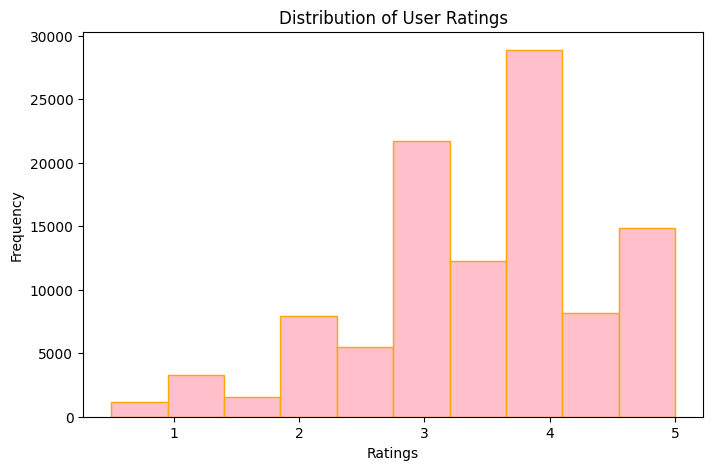

In [14]:
#Visualizations
#1.Histogram-How users rate movies
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(8, 5))

# Plot histogram
plt.hist(Ratings['rating'], bins=10, color='pink', edgecolor='orange')

# Add title and labels
plt.title('Distribution of User Ratings')
plt.xlabel('Ratings')
plt.ylabel('Frequency')

# Show the plot
plt.show()

#Output
#Most user ratings are concentrated between 3.0 and 5.0, showing a strong preference for higher ratings.
#The most common rating is around 4.0, while low ratings are rare and gaps appear due to discrete rating values.

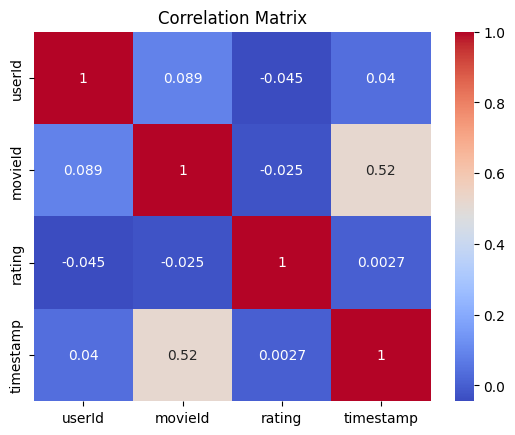

In [15]:
#2.#Seaborn Heatmap — Correlation Matrix
#Identify which features are mostly related
import seaborn as sns

#Correlation matrix
corr = Ratings[['userId', 'movieId', 'rating', 'timestamp']].corr()

# Plot heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

#Output
#The correlation matrix shows that most variables have weak relationships, with only a moderate correlation between movieId and timestamp, while ratings are largely independent of other features.


In [16]:
#3. Feature Engineering and Selection 
#i)Merge Movies and Ratings on movieId
df = Ratings.merge(Movies, on='movieId')

In [17]:
#ii)Create meaningful features
# Extract year from title
df['year'] = df['title'].str.extract(r'\((\d{4})\)')

# Convert year to numeric
df['year'] = pd.to_numeric(df['year'], errors='coerce')

# Example: Count number of genres
df['genre_count'] = df['genres'].apply(lambda x: len(x.split('|')))

In [18]:
#iii)Encode categorical variables (genres)
# One-hot encode genres
genres_encoded = df['genres'].str.get_dummies(sep='|')

In [19]:
#iv)Feature selection (correlation check)
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr = numeric_df.corr()

print(corr['rating'].sort_values(ascending=False))


rating         1.000000
genre_count    0.029696
movieId       -0.025455
userId        -0.044780
year          -0.096331
Name: rating, dtype: float64


In [20]:
#v)Encode genres
genres_encoded = Movies['genres'].str.get_dummies(sep='|')

In [21]:
#vi)Drop unnecessary columns
df = df.drop(columns=['title', 'genres'],errors='ignore')

In [22]:
#4Model Building 
#Similarity-based
#Content based recommendations
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(genres_encoded)

In [23]:
# View Movie Similarity Content-Based Model as Table
similarity_df = pd.DataFrame(similarity)

print(similarity_df.head())


      0         1         2         3         4      5         6      \
0  1.000000  0.774597  0.316228  0.258199  0.447214    0.0  0.316228   
1  0.774597  1.000000  0.000000  0.000000  0.000000    0.0  0.000000   
2  0.316228  0.000000  1.000000  0.816497  0.707107    0.0  1.000000   
3  0.258199  0.000000  0.816497  1.000000  0.577350    0.0  0.816497   
4  0.447214  0.000000  0.707107  0.577350  1.000000    0.0  0.707107   

      7      8         9      ...     10319    10320  10321     10322  \
0  0.632456    0.0  0.258199  ...  0.000000  0.00000    0.0  0.316228   
1  0.816497    0.0  0.333333  ...  0.000000  0.00000    0.0  0.000000   
2  0.000000    0.0  0.000000  ...  0.000000  0.00000    0.0  0.500000   
3  0.000000    0.0  0.000000  ...  0.333333  0.57735    0.0  0.816497   
4  0.000000    0.0  0.000000  ...  0.000000  0.00000    0.0  0.707107   

     10323     10324     10325     10326    10327  10328  
0  0.00000  0.774597  0.447214  0.447214  0.00000    0.0  
1  0.00000

In [24]:
#Movie Recommendations
def recommend_movies(movie_title, top_n=5):
    idx = Movies[Movies['title'] == movie_title].index[0]
    scores = list(enumerate(similarity[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    movie_indices = [i[0] for i in scores[1:top_n+1]]
    return Movies.iloc[movie_indices]['title'].reset_index(drop=True)

In [25]:
#Top 5 recommended movies
print("Recommended movies:")
print(recommend_movies("Toy Story (1995)"))
#“Toy Story (1995)” is intentionally excluded because the system removes the movie itself from the recommendations.

Recommended movies:
0                                       Antz (1998)
1                                Toy Story 2 (1999)
2    Adventures of Rocky and Bullwinkle, The (2000)
3                  Emperor's New Groove, The (2000)
4                             Monsters, Inc. (2001)
Name: title, dtype: object


In [26]:
# Collaborative Filtering 
# Create user-movie matrix
user_movie_matrix = Ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
).fillna(0)

In [27]:
# Compute similarity between users
user_similarity = cosine_similarity(user_movie_matrix)


In [28]:
#View User Similarity Collaborative Filtering Model As table
user_sim_df = pd.DataFrame(user_similarity)

print(user_sim_df.head())


        0         1         2         3         4         5         6    \
0  1.000000  0.101113  0.210044  0.128766  0.057896  0.077130  0.358090   
1  0.101113  1.000000  0.115559  0.034610  0.032705  0.028305  0.062914   
2  0.210044  0.115559  1.000000  0.058208  0.044426  0.012816  0.084522   
3  0.128766  0.034610  0.058208  1.000000  0.019298  0.005781  0.059089   
4  0.057896  0.032705  0.044426  0.019298  1.000000  0.053378  0.080822   

        7         8         9    ...       658       659       660       661  \
0  0.097434  0.239189  0.026663  ...  0.291162  0.144741  0.106583  0.091049   
1  0.471918  0.194232  0.000000  ...  0.068325  0.000000  0.477330  0.146887   
2  0.066620  0.459703  0.068454  ...  0.152078  0.301021  0.081626  0.098949   
3  0.024420  0.050572  0.000000  ...  0.055860  0.024329  0.040467  0.108881   
4  0.041536  0.023168  0.011915  ...  0.058450  0.007315  0.024708  0.038163   

        662       663       664       665       666       667  
0  0